<a href="https://colab.research.google.com/github/rozbloom/AI_Academic_assistant_for_african_university_students/blob/main/module1_health_screening_assignment_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Patient ID                      0
Age                             0
Gender                          0
Height (cm)                     0
Weight (kg)                     0
Systolic BP                     0
Diastolic BP                    0
Blood Sugar (mg/dL)             0
Physical Activity (hrs/week)    0
Smoking Status                  0
dtype: int64
  Patient ID   Age  Gender  Height (cm)  Weight (kg)  Systolic BP  \
0       P001  34.0    Male          175           78          122   
1       P002  45.0  Female          162           68          130   
2       P003  29.0    Male          180           82          118   
3       P004  45.0    Male          158           74          140   
4       P005  61.0    Male          170           88          150   

   Diastolic BP  Blood Sugar (mg/dL)  Physical Activity (hrs/week)  \
0            80                   95                           3.5   
1            85                  105                           1.0   
2            76       

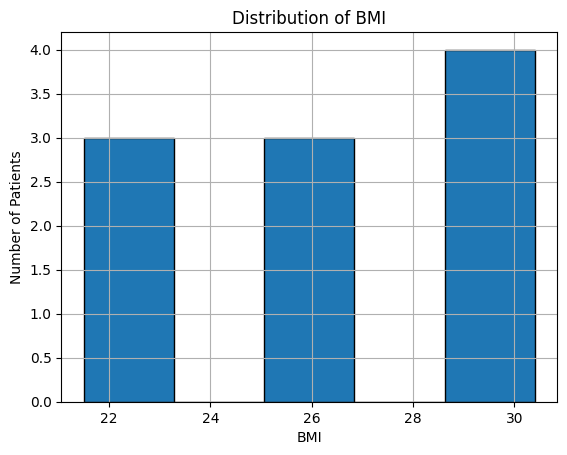

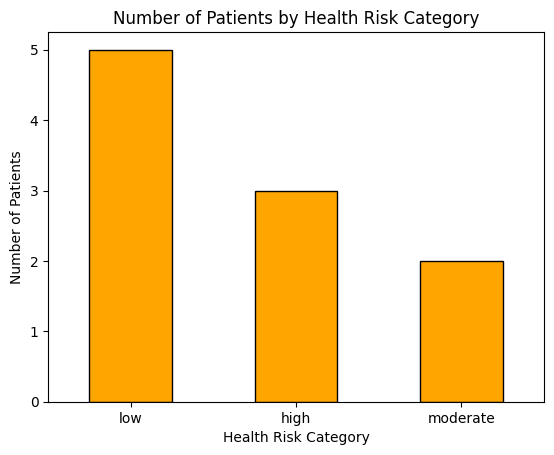

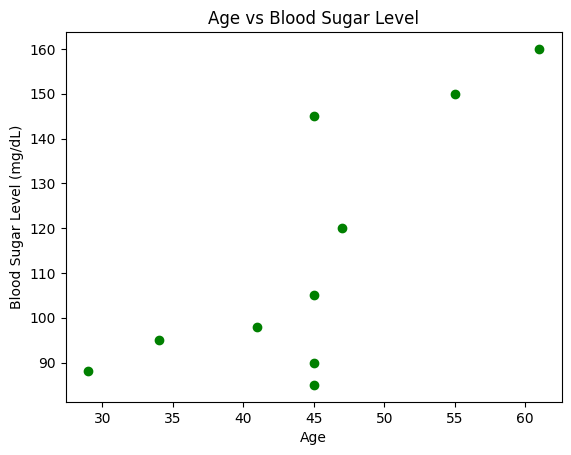

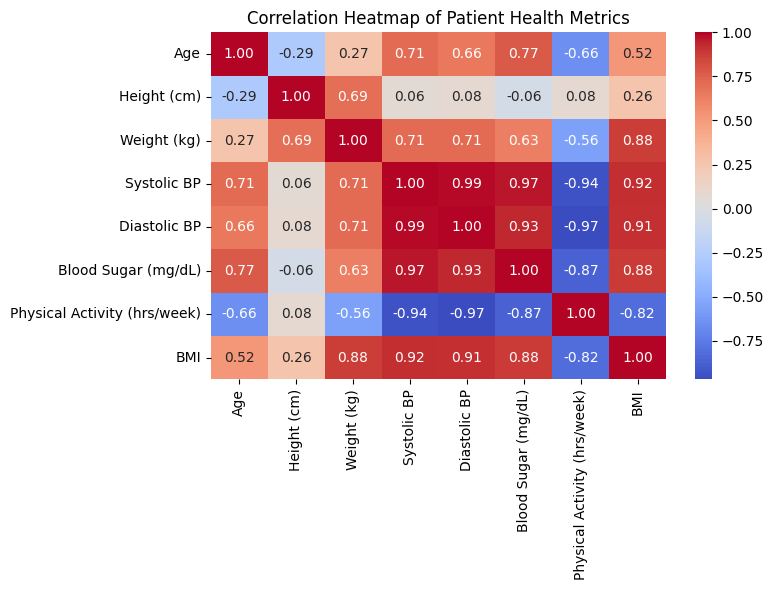

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

patients = [
    {"Patient ID": "P001", "Age": 34, "Gender": "Male", "Height (cm)": 175, "Weight (kg)": 78, "Systolic BP": 122, "Diastolic BP": 80, "Blood Sugar (mg/dL)": 95, "Physical Activity (hrs/week)": 3.5, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P002", "Age": 45, "Gender": "Female", "Height (cm)": 162, "Weight (kg)": 68, "Systolic BP": 130, "Diastolic BP": 85, "Blood Sugar (mg/dL)": 105, "Physical Activity (hrs/week)": 1.0, "Smoking Status": "Smoker"},
    {"Patient ID": "P003", "Age": 29, "Gender": "Male", "Height (cm)": 180, "Weight (kg)": 82, "Systolic BP": 118, "Diastolic BP": 76, "Blood Sugar (mg/dL)": 88, "Physical Activity (hrs/week)": 5.0, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P004", "Age": None, "Gender": None, "Height (cm)": 158, "Weight (kg)": 74, "Systolic BP": 140, "Diastolic BP": 90, "Blood Sugar (mg/dL)": 145, "Physical Activity (hrs/week)": 0.5, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P005", "Age": 61, "Gender": "Male", "Height (cm)": 170, "Weight (kg)": 88, "Systolic BP": 150, "Diastolic BP": 95, "Blood Sugar (mg/dL)": 160, "Physical Activity (hrs/week)": 0.0, "Smoking Status": "Smoker"},
    {"Patient ID": "P006", "Age": None, "Gender": None, "Height (cm)": 165, "Weight (kg)": 60, "Systolic BP": 115, "Diastolic BP": 75, "Blood Sugar (mg/dL)": 90, "Physical Activity (hrs/week)": 4.0, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P007", "Age": 47, "Gender": "Male", "Height (cm)": 177, "Weight (kg)": 95, "Systolic BP": 135, "Diastolic BP": 88, "Blood Sugar (mg/dL)": 120, "Physical Activity (hrs/week)": 1.5, "Smoking Status": "Smoker"},
    {"Patient ID": "P008", "Age": None, "Gender": "Female", "Height (cm)": 160, "Weight (kg)": 55, "Systolic BP": 110, "Diastolic BP": 70, "Blood Sugar (mg/dL)": 85, "Physical Activity (hrs/week)": 6.0, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P009", "Age": 55, "Gender": "Male", "Height (cm)": 172, "Weight (kg)": 90, "Systolic BP": 145, "Diastolic BP": 92, "Blood Sugar (mg/dL)": 150, "Physical Activity (hrs/week)": 0.5, "Smoking Status": "Smoker"},
    {"Patient ID": "P010", "Age": 41, "Gender": "Female", "Height (cm)": 168, "Weight (kg)": 65, "Systolic BP": 125, "Diastolic BP": 82, "Blood Sugar (mg/dL)": 98, "Physical Activity (hrs/week)": 2.5, "Smoking Status": "Non-Smoker"},
    {"Patient ID": "P001", "Age": 34, "Gender": "Male", "Height (cm)": 175, "Weight (kg)": 78, "Systolic BP": 122, "Diastolic BP": 80, "Blood Sugar (mg/dL)": 95, "Physical Activity (hrs/week)": 3.5, "Smoking Status": "Non-Smoker"},
]

df=pd.DataFrame(patients)
df=df.drop_duplicates()
df ["Age"] = df["Age"].fillna(df["Age"].median())
df ["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])
print(df.isnull().sum())
print(df.head())

df ["BMI"] = (df ["Weight (kg)"] / ((df ["Height (cm)"] / 100) ** 2)).round(1)
df.head()

def BP(Systolic, Diastolic):
  if Systolic < 120 and Diastolic < 80 :
    return "Normal"
  elif Systolic < 130 and Diastolic < 80:
        return "Elevated"
  elif Systolic < 140 or Diastolic < 90:
        return "High - Stage 1"
  else:
        return "High - Stage 2"
df["BP"] = df.apply(lambda row: BP(row["Systolic BP"], row["Diastolic BP"]), axis=1)


def health_risk(row):
  risk_score = 0

  if row["BMI"] >= 30 or row["BMI"] < 18.5:
    risk_score += 1
  if row["Systolic BP"] >= 140 or row["Diastolic BP"] >= 90:
    risk_score += 1
  if row["Blood Sugar (mg/dL)"] >= 126:
    risk_score += 1
  if row ["Smoking Status"] == "Smoker":
    risk_score += 1
  if row ["Physical Activity (hrs/week)"] <= 1:
    risk_score += 1

  if risk_score >= 3:
    return "high"
  elif risk_score >= 1:
    return "moderate"
  else :
    return "low"
df["health risk"] = df.apply(health_risk, axis=1)


print("mean:", np.mean(df["BMI"]).round(1))
print("min:", np.min(df["BMI"]))
print("max:", np.max(df["BMI"]))
print("std:", np.std(df["BMI"]))

print("mean:", np.mean(df["Blood Sugar (mg/dL)"].round(1)))
print("min:", np.min(df["Blood Sugar (mg/dL)"]))
print("max:", np.max(df["Blood Sugar (mg/dL)"]))
print("std:", np.std(df["Blood Sugar (mg/dL)"]))

print(df.groupby("Gender")["BMI"].mean())
print(df.groupby("Gender")["Age"].mean())
print(df.groupby("Gender")["Blood Sugar (mg/dL)"].mean())

def BMI_Category(BMI):
      if BMI < 18.5:
          return "Underweight"
      elif BMI < 25:
          return "Normal"
      elif BMI < 30:
          return "Overweight"
      else:
          return "Obese"
df["BMI_Category"] = df["BMI"].apply(BMI_Category)
print(df["BMI_Category"].value_counts())
print(df["health risk"].value_counts())

smokers = df[df["Smoking Status"] == "Smoker"]
percentage = (len(smokers) / len(df)) * 100
print(percentage)

# Chart 1: BMI Histogram
df["BMI"].hist(bins=5, edgecolor="black")
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.show()

# Chart 2: Health Risk Bar Chart
df["health risk"].value_counts().plot(kind="bar", color="orange", edgecolor="black")
plt.title("Number of Patients by Health Risk Category")
plt.xlabel("Health Risk Category")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()


plt.scatter(df["Age"], df["Blood Sugar (mg/dL)"], color="green")
plt.title("Age vs Blood Sugar Level")
plt.xlabel("Age")
plt.ylabel("Blood Sugar Level (mg/dL)")
plt.show()


corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Patient Health Metrics")
plt.tight_layout()
plt.show()